In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.preprocessing import LabelEncoder

In [1]:
import cv2
import os

students = ["shivam"]
save_dir = "dataset"

for student in students:
    student_folder = os.path.join(save_dir, student)
    os.makedirs(student_folder, exist_ok=True)

camera_url = "http://192.168.126.204:4747/video" 
cap = cv2.VideoCapture(camera_url)

print("Press 's' to select student.")
print("Press 'c' to capture one image.")
print("Press 'q' to quit.")

selected_student = None
count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        print("Camera error! Check your connection.")
        break

    cv2.imshow("Camera Feed", frame)
    key = cv2.waitKey(1) & 0xFF

    if key == ord('s'): 
        print("\nAvailable students:")
        for idx, student in enumerate(students, start=1):
            print(f"{idx}. {student}")
        try:
            student_index = int(input("Enter student number (1-n): ")) - 1
            if 0 <= student_index < len(students):
                selected_student = students[student_index]
                count = 0
                print(f"Selected {selected_student}. Start capturing images!")
            else:
                print("Invalid selection. Try again.")
        except ValueError:
            print("Please enter a valid number.")

    if key == ord('c') and selected_student:
        if count < 50:
            img_path = os.path.join(save_dir, selected_student, f"img_{count+1}.jpg")
            cv2.imwrite(img_path, frame)
            print(f"Captured image {count+1} for {selected_student}")
            count += 1
            if count == 50:
                print(f"Finished capturing 50 images for {selected_student}.")
                selected_student = None
        else:
            print(f"Already captured 50 images for {selected_student}.")

    if key == ord('q'):
        print("Quitting...")
        break

cap.release()
cv2.destroyAllWindows()


Press 's' to select student.
Press 'c' to capture one image.
Press 'q' to quit.
Quitting...


In [6]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

data = []
labels = []
class_names = os.listdir("dataset")

for idx, person in enumerate(class_names):
    person_folder = os.path.join("dataset", person)
    for img_name in os.listdir(person_folder):
        img_path = os.path.join(person_folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))
        img = img / 255.0
        data.append(img)
        labels.append(idx)

data = np.array(data)
labels = np.array(labels)

labels = to_categorical(labels, num_classes=len(class_names))

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=x)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


In [ ]:
model.fit(X_train, y_train, epochs=10, batch_size=8, validation_data=(X_test, y_test))


model.save("face_recognition_mobilenet.h5")

In [7]:

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=val_datagen.flow(X_test, y_test, batch_size=32),
    callbacks=[early_stopping]
)

model.save("face_recognition_model.h5")

c:\Users\91999\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4437 - loss: 1.6281 - val_accuracy: 0.7500 - val_loss: 0.4233
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9612 - loss: 0.2068 - val_accuracy: 1.0000 - val_loss: 0.0464
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9871 - loss: 0.0672 - val_accuracy: 1.0000 - val_loss: 0.0553
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 980ms/step - accuracy: 1.0000 - loss: 0.0162 - val_accuracy: 1.0000 - val_loss: 0.0608
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 979ms/step - accuracy: 1.0000 - loss: 0.0085 - val_accuracy: 1.0000 - val_loss: 0.0229
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 986ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 0.0093
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 0.0055
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 982ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 0.0043
Epo

In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

data = []
labels = []
class_names = os.listdir("dataset")

for idx, person in enumerate(class_names):
    person_folder = os.path.join("dataset", person)
    for img_name in os.listdir(person_folder):
        img_path = os.path.join(person_folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))
        img = img / 255.0 
        data.append(img)
        labels.append(idx)


data = np.array(data)
labels = np.array(labels)

labels = to_categorical(labels, num_classes=len(class_names))

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=x)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

model.save("face_recognition_EfficientNetB0.h5")

print("Model trained and saved successfully!")


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.2720 - loss: 1.4195 - val_accuracy: 0.2500 - val_loss: 1.4569
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2540 - loss: 1.4294 - val_accuracy: 0.2250 - val_loss: 1.3860
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2560 - loss: 1.4207 - val_accuracy: 0.1500 - val_loss: 1.3996
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3239 - loss: 1.3944 - val_accuracy: 0.1500 - val_loss: 1.4657
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2874 - loss: 1.3894 - val_accuracy: 0.1500 - val_loss: 1.4371
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2115 - loss: 1.3946 - val_accuracy: 0.2500 - val_loss: 1.3949
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2002 - loss: 1.3993 - val_accuracy: 0.2250 - val_loss: 1.4259
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2911 - loss: 1.3922 - val_accuracy: 0.2250 - val_loss: 1.4571
Epoch 9/10
5/5 

✅ Model trained and saved successfully!


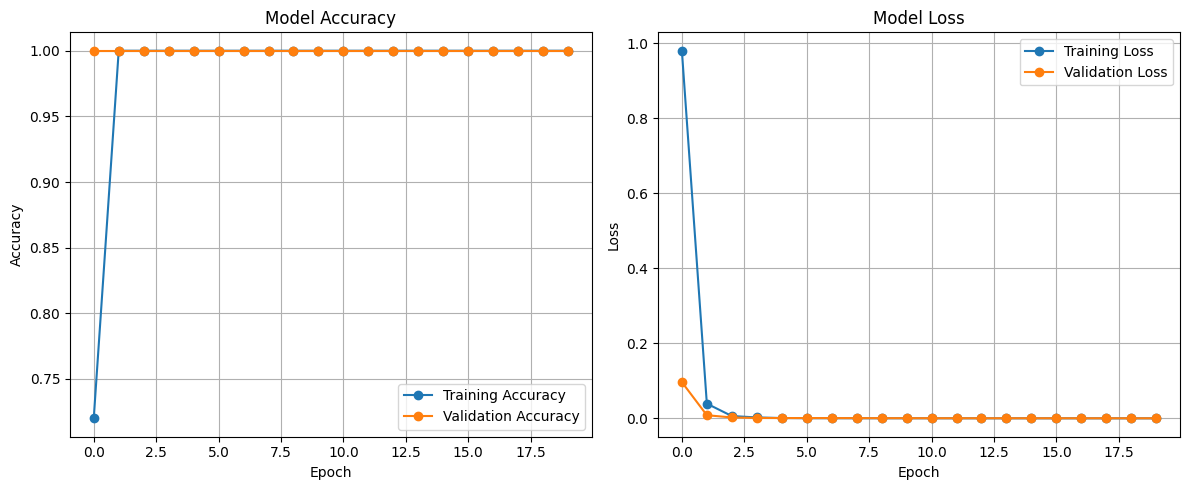

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


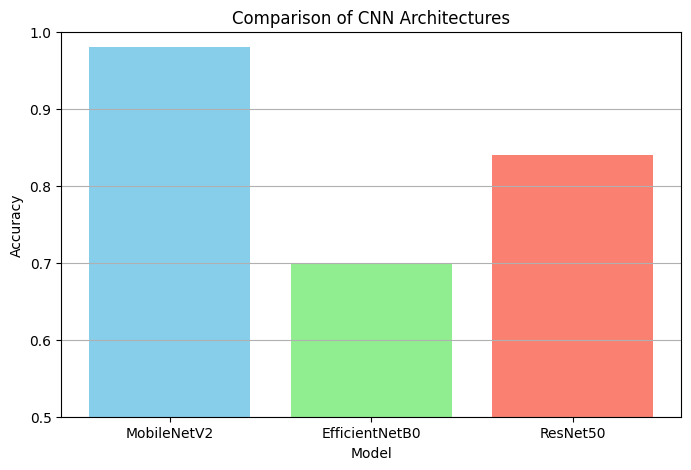

In [13]:
import matplotlib.pyplot as plt

frameworks = ['MobileNetV2', 'EfficientNetB0', 'ResNet50']
accuracies = [0.98, 0.70, 0.84]

plt.figure(figsize=(8,5))
plt.bar(frameworks, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0.5, 1)
plt.title('Comparison of CNN Architectures')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.grid(axis='y')
plt.show()
